In [1]:
# Q1
print("(A,d)")
print("(B,c)")
print("(C,b)")
print("(D,a)")

(A,d)
(B,c)
(C,b)
(D,a)


In [2]:
# Q2
print("(A,b)")
print("(B,e)")
print("(C,c)")
print("(D,a)")
print("(E,d)")

(A,b)
(B,e)
(C,c)
(D,a)
(E,d)


In [3]:
# Q3
from bs4 import BeautifulSoup
import re
import pandas as pd

pd.set_option("display.max_columns", None)

filename = "page_sources/rotten_tomatoes_popular.html"
with open(filename) as f:
    soup = BeautifulSoup(f, "html.parser")
    
movie_data_list = soup.find_all("div", class_="flex-container")

movies = []
records = []
count = 0

for movie_data in movie_data_list:
    title_tag = movie_data.find("span", {"data-qa": "discovery-media-list-item-title"})
    title = title_tag.get_text(strip=True) if title_tag else None
    
    critic_tag = movie_data.find("rt-text", {"slot": "criticsScore"})
    critic_score = int(re.search(r"\d+", critic_tag.text).group()) if critic_tag and critic_tag.text.strip() else None
    audience_tag = movie_data.find("rt-text", {"slot": "audienceScore"})
    audience_score = int(re.search(r"\d+", audience_tag.text).group()) if audience_tag and audience_tag.text.strip() else None
    
    date_tag = movie_data.find("span", {"data-qa": "discovery-media-list-item-start-date"})
    date = date_tag.get_text(strip=True) if date_tag else None
    month = day = year = None
    
    if date_tag and "Streaming" in date_tag.text:
        text = date_tag.get_text(strip=True)
        parts = text.replace("Streaming ", "").split()   
        if len(parts) == 3:
            month, day, year = parts
            month_str = {"Jan":1, "Feb":2, "Mar":3, "Apr":4, "May":5, "Jun":6, "Jul":7, "Aug":8, "Sep":9, "Oct":10, "Nov":11, "Dec":12}
            month = month_str[month]
            day = day.rstrip(",")
        
    if title and critic_score and audience_score and date and month and day:
        if count == 300:
            break
            
        records.append({
            "title": title,
            "critic_rating": critic_score,
            "user_rating": audience_score,
            "month": month,
            "day": day,
            "year": year
        })  
        
        count += 1

movies_lowdim = pd.DataFrame(records).astype({
    "title": str,
    "critic_rating": int,
    "user_rating": int,
    "month": int,
    "day": int,
    "year": int
})

movies_lowdim.to_excel("movies_lowdim.xlsx")
movies_lowdim.head(10)

,title,critic_rating,user_rating,month,day,year
0,The Woman in Cabin 10,28,32,10,10,2025
1,The Perfect Neighbor,100,73,10,17,2025
2,Weapons,93,85,9,9,2025
3,Evelyn,100,77,9,10,2019
4,The Lost Bus,87,94,10,3,2025
5,The Substance,89,76,10,31,2024
6,Bring Her Back,89,79,7,1,2025
7,HIM,31,57,10,7,2025
8,A HOUSE OF DYNAMITE,81,76,10,24,2025
9,The Conjuring: Last Rites,59,78,10,7,2025


user_ratings: mean:74.94, std:16.77, 25th percentile:66.00, 75th percentile:88.00
critic_ratings: mean:74.85, std:22.68, 25th percentile:63.00, 75th percentile:92.00


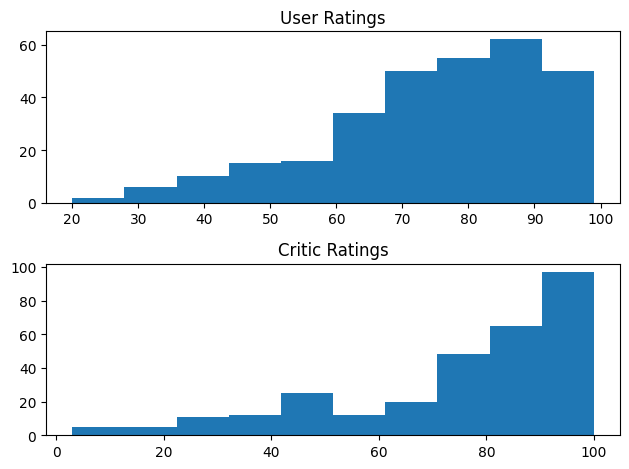

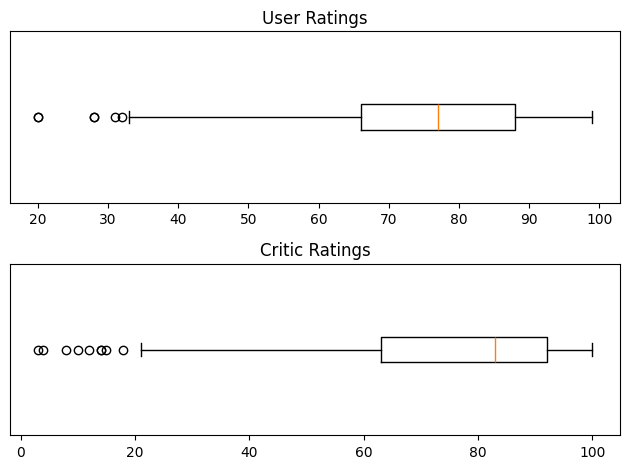

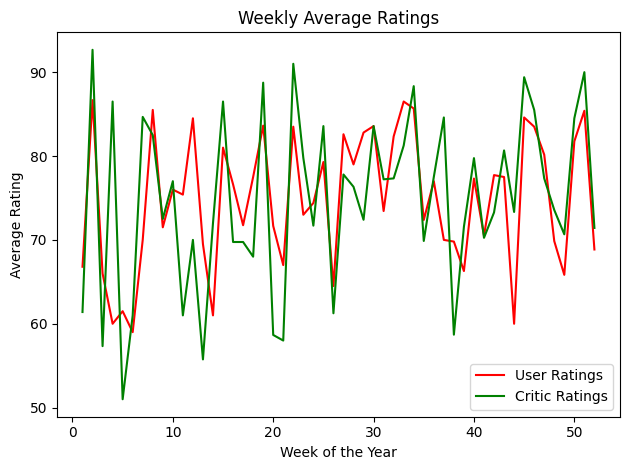

Correlation of user and critic ratings: 0.5793


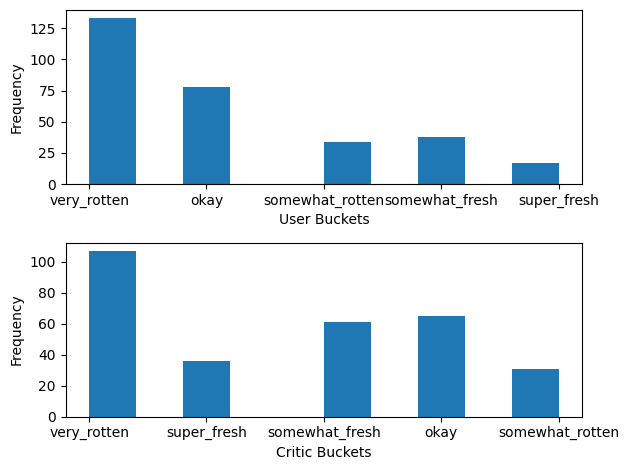

Most frequent user bucket: very_rotten
Most frequent critic bucket: very_rotten


In [4]:
# Q4
import numpy as np
import matplotlib.pyplot as plt

# Q4a
user_data = movies_lowdim["user_rating"]
print(f"user_ratings: mean:{user_data.mean():.2f}, std:{user_data.std():.2f}, 25th percentile:{np.percentile(user_data, 25):.2f}, 75th percentile:{np.percentile(user_data, 75):.2f}")

critic_data = movies_lowdim["critic_rating"]
print(f"critic_ratings: mean:{critic_data.mean():.2f}, std:{critic_data.std():.2f}, 25th percentile:{np.percentile(critic_data, 25):.2f}, 75th percentile:{np.percentile(critic_data, 75):.2f}")

# Q4b
plt.subplot(2,1,1)
plt.hist(user_data)
plt.title("User Ratings")

plt.subplot(2,1,2)
plt.hist(critic_data)
plt.title("Critic Ratings")

plt.tight_layout()
plt.show()

# Q4c
plt.subplot(2,1,1)
plt.boxplot(user_data, orientation='horizontal')
plt.title("User Ratings")
plt.yticks([])


plt.subplot(2,1,2)
plt.boxplot(critic_data, orientation='horizontal')
plt.title("Critic Ratings")
plt.yticks([])

plt.tight_layout()
plt.show()

# Q4d
movies_lowdim["date"] = pd.to_datetime(movies_lowdim[["year", "month", "day"]])
movies_lowdim["week"] = movies_lowdim["date"].dt.isocalendar().week

weekly_avg = movies_lowdim.groupby("week")[["user_rating", "critic_rating"]].mean()
movies_lowdim = movies_lowdim.drop(["date", "week"], axis=1)

plt.plot(weekly_avg.index, weekly_avg["user_rating"], color="red", label="User Ratings")
plt.plot(weekly_avg.index, weekly_avg["critic_rating"], color="green", label="Critic Ratings")
plt.title("Weekly Average Ratings")
plt.xlabel("Week of the Year")
plt.ylabel("Average Rating")
plt.legend()

plt.tight_layout()
plt.show()

# Q4e
print(f"Correlation of user and critic ratings: {movies_lowdim["user_rating"].corr(movies_lowdim["critic_rating"]):.4f}")

# Q4f
def bucketize(score) -> str:
    if score > 95:
        return "super_fresh"
    elif score > 90:
        return "somewhat_fresh"
    elif score > 80:
        return "okay"
    elif score > 75:
        return "somewhat_rotten"
    else:
        return "very_rotten"
    
movies_lowdim["user bucket"] = movies_lowdim["user_rating"].apply(lambda x: bucketize(x))
movies_lowdim["critic bucket"] = movies_lowdim["critic_rating"].apply(lambda x: bucketize(x))

plt.subplot(2,1,1)
plt.hist(movies_lowdim["user bucket"])
plt.xlabel("User Buckets")
plt.ylabel("Frequency")

plt.subplot(2,1,2)
plt.hist(movies_lowdim["critic bucket"])
plt.xlabel("Critic Buckets")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

print("Most frequent user bucket:", (movies_lowdim["user bucket"].value_counts()).idxmax())
print("Most frequent critic bucket:", (movies_lowdim["critic bucket"].value_counts()).idxmax())

# Q4g
def bucketize(score) -> str:
    if score > 90:
        return "3"
    elif score > 80:
        return "2"
    else:
        return "1"
    
movies_lowdim["user bucket number"] = movies_lowdim["user_rating"].apply(lambda x: bucketize(x))
movies_lowdim["critic bucket number"] = movies_lowdim["critic_rating"].apply(lambda x: bucketize(x))

In [5]:
# Q5
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

X1 = movies_lowdim[["critic bucket number"]]
X2 = movies_lowdim[["critic_rating"]]
X3 = movies_lowdim[["month", "critic bucket number"]]

bucket_order = ["very_rotten", "somewhat_rotten", "okay", "somewhat_fresh", "super_fresh"]
bucket_map = {label: i for i, label in enumerate(bucket_order)}
X4 = movies_lowdim[["month", "year", "day"]].copy()
X4["critic_bucket_num"] = movies_lowdim["critic bucket"].map(bucket_map)

y = movies_lowdim["user bucket number"]

results = []

clf = DecisionTreeClassifier(random_state=42)
print("Algorithm: DecisionTreeClassifier")
for i, X in enumerate([X1, X2, X3, X4], start=1):
    scores = cross_val_score(clf, X, y, cv=5)
    test_acc = np.mean(scores)
    clf.fit(X, y)
    train_acc = clf.score(X, y)
    print(f"Scenario {i}: {train_acc:.3f} {test_acc:.3f}")
    results.append((f"DecisionTreeClassifier, Scenario {i}", float(train_acc), float(test_acc)))
    
clf = RandomForestClassifier(n_estimators=10, random_state=42)
print("\nAlgorithm: RandomForestClassifier")
for i, X in enumerate([X1, X2, X3, X4], start=1):
    scores = cross_val_score(clf, X, y, cv=5)
    test_acc = scores.mean()
    clf.fit(X, y)
    train_acc = clf.score(X, y)
    print(f"Scenario {i}: {train_acc:.3f} {test_acc:.3f}")
    results.append((f"RandomForestClassifier, Scenario {i}", float(train_acc), float(test_acc)))

best_scenario = max(results, key=lambda x: x[2])
print("\n" + best_scenario[0])

Algorithm: DecisionTreeClassifier
Scenario 1: 0.557 0.557
Scenario 2: 0.663 0.537
Scenario 3: 0.630 0.527
Scenario 4: 0.940 0.477

Algorithm: RandomForestClassifier
Scenario 1: 0.557 0.557
Scenario 2: 0.650 0.517
Scenario 3: 0.617 0.487
Scenario 4: 0.907 0.490

DecisionTreeClassifier, Scenario 1


In [6]:
# Q6
print("(A,b)")
print("(B,a)")
print("(C,c)")

(A,b)
(B,a)
(C,c)


In [7]:
# Q7
import random
import os
import datetime
import pickle

random.seed(42)
random_numbers = [random.randint(0, 300) for _ in range(15)]
random_movies = movies_lowdim.loc[random_numbers]

display(random_movies[["title", "user bucket", "critic bucket"]])

files = ["maintenance_required.html",
"steve_2025.html",
"its_whats_inside.html",
"28_days_later.html",
"the_babadook.html",
"past_lives.html",
"heretic_2024.html",
"juror_2.html",
"nobody_2.html",
"there_will_be_blood.html",
"the_strangers_chapter_2.html",
"superman_2025.html",
"the_ugly_stepsister.html",
"the_order_2024.html",
"it_2017.html"]

movie_raw = {}

for i, filename in enumerate(files):
    path = os.path.join("page_sources", filename)
    with open(path, encoding="utf-8") as f:
        html = f.read()
        
    soup = BeautifulSoup(html, "html.parser")

    tag = soup.find("meta", {"property": "og:title"})
    title = tag["content"].replace("| Reviews", "").strip().lower() if tag else "not_available"
    
    details = soup.select_one('ul[data-qa="sidebar-movie-details"] li')
    if details:
        text = details.get_text(strip=True)
        match = re.search(r'\b(G|PG|PG-13|R|NC-17)\b', text)
        designation = match.group(0).lower() if match else "not_available"
    else:
        designation = "not_available"
        
    items = soup.select('ul[data-qa="sidebar-movie-details"] li')
    genres = ["not_available"]

    if len(items) > 1:
        text = items[1].get_text(strip=True).lower()
        genres = [g.strip() for g in text.split(",")] if text else ["not_available"]

    director_tag = soup.select_one('li:has(a[href*="/celebrity/"]) a')
    director_name = director_tag.get_text(strip=True).lower() if director_tag else "not_available"
    
    in_theaters_tag = soup.find("li", string=re.compile(r"In Theaters:", re.I))
    if in_theaters_tag:
        date_text = in_theaters_tag.get_text(strip=True).replace("In Theaters:", "").strip()
        try:
            in_theatres = datetime.datetime.strptime(date_text, "%b %d, %Y")
        except ValueError:
            in_theatres = "not_available"
    else:
        in_theatres = "not_available"
    
    streaming_tag = soup.find("li", string=re.compile(r"Streaming:", re.I))
    if streaming_tag:
        date_text = streaming_tag.get_text(strip=True).replace("Streaming:", "").strip()
        try:
            streaming = datetime.datetime.strptime(date_text, "%b %d, %Y")
        except ValueError:
            streaming = "not_available"
    else:
        streaming = "not_available"
    
    reviews = []
    
    for review_row in soup.select('div.review-row[data-qa="review-item"]'):
        if len(reviews) >= 5:
            break

        author_tag = review_row.select_one('a[data-qa="review-critic-link"]')
        author = author_tag.get_text(strip=True).lower() if author_tag else "not_available"
        
        publication_tag = review_row.select_one('a[data-qa="review-publication"]')
        publication = publication_tag.get_text(strip=True).lower() if publication_tag else "not_available"
        
        text_tag = review_row.select_one('p[data-qa="review-quote"]')
        review_text = text_tag.get_text(strip=True).lower() if text_tag else "not_available"
        
        score_tag = review_row.select_one('score-icon-critics')
        sentiment = score_tag.get('sentiment', '').lower() if score_tag else "not_available"
        review_fresh = 1 if sentiment == "positive" else 0 if sentiment == "negative" else "not_available"
        
        match = None
        original_score_tag = review_row.select_one('p.original-score-and-url')
        patterns = [r'\b([A-F][+-]?)\b', r'\b(\d{1,3}(?:\.\d+)?)\b', r'\b(\d{1,2}(?:\.\d+)?/\d{1,2}(?:\.\d+)?)\b']
        for pattern in patterns:
            match = re.search(pattern, original_score_tag.get_text() if original_score_tag else "")
            if match:
                break
        

        review_score = match.group(1).lower() if match else "not_available"
        
        # review_score_match = re.search(r'Original Score:\s*([A-F][+-]?)', original_score_tag.get_text() if original_score_tag else "")
        # review_score = review_score_match.group(1).lower() if review_score_match else "not_available"

        reviews.append({
            "review_author": author,
            "review_publication": publication,
            "review_text": review_text,
            "review_fresh": review_fresh,
            "review_score": review_score
        })
        
    movie_raw[i] = {"movie_title": title,
                    "designation": designation,
                    "genres": genres,
                    "director_name": director_name,
                    "in_theatres": in_theatres,
                    "streaming": streaming,
                    "reviews": reviews}

with open("movie_raw.pkl", "wb") as f:
    pickle.dump(movie_raw, f)

,title,user bucket,critic bucket
57,Maintenance Required,very_rotten,very_rotten
12,Steve,very_rotten,somewhat_rotten
140,It's What's Inside,very_rotten,somewhat_rotten
125,28 Days Later,okay,okay
114,The Babadook,very_rotten,super_fresh
71,Past Lives,somewhat_fresh,somewhat_fresh
52,Heretic,somewhat_rotten,okay
279,Juror #2,okay,somewhat_fresh
44,Nobody 2,okay,somewhat_rotten
216,There Will Be Blood,okay,somewhat_fresh


In [32]:
# Q8
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import CountVectorizer
import math
    
movies_highdim = random_movies.copy()
movies_highdim = movies_highdim.reset_index(drop=True)
movies_highdim["title"] = [movie_raw[i]["movie_title"] for i in range(len(movie_raw))]
movies_highdim = movies_highdim.rename(columns={"user bucket number":"user_bucket_number", "critic bucket number":"critic_bucket_number"})
movies_highdim = movies_highdim.drop(columns=["critic_rating", "user_rating", "month", "day", "year", "user bucket", "critic bucket"])

unique_designations = sorted({movie_raw[i]["designation"] for i in range(len(movie_raw))})
designation_map = {d: idx+1 for idx, d in enumerate(unique_designations)}
movies_highdim["designation"] = [designation_map.get(movie_raw[i]["designation"], 0) for i in range(len(movie_raw))]

genre_lists = [movie_raw[i]["genres"] for i in range(len(movie_raw))]
mlb = MultiLabelBinarizer()
genres_encoded = mlb.fit_transform(genre_lists)
genres_df = pd.DataFrame(genres_encoded, columns=mlb.classes_)
movies_highdim = pd.concat([movies_highdim.reset_index(drop=True), genres_df.reset_index(drop=True)], axis=1)

unique_directors = sorted({movie_raw[i]["director_name"] for i in range(len(movie_raw))})
director_map = {d: idx+1 for idx, d in enumerate(unique_directors)}
movies_highdim["director_name"] = [director_map.get(movie_raw[i]["director_name"], 0) for i in range(len(movie_raw))]

def parse_date(date_val):
    if isinstance(date_val, datetime.datetime):
        return date_val.isocalendar()[1], date_val.month, date_val.year
    else:
        return 0, 0, 0

weeks, months, years = [], [], []
for i in range(len(movie_raw)):
    w, m, y = parse_date(movie_raw[i]["in_theatres"])
    weeks.append(w)
    months.append(m)
    years.append(y)
    
movies_highdim["in_theatres_week"] = weeks
movies_highdim["in_theatres_month"] = months
movies_highdim["in_theatres_year"] = years

weeks, months, years = [], [], []
for i in range(len(movie_raw)):
    w, m, y = parse_date(movie_raw[i]["streaming"])
    weeks.append(w)
    months.append(m)
    years.append(y)
    
movies_highdim["streaming_week"] = weeks
movies_highdim["streaming_month"] = months
movies_highdim["streaming_year"] = years

all_authors, all_publication = set(), set()
for movie in movie_raw.values():
    for review in movie.get("reviews", []):
        author = review.get("review_author")
        publication = review.get("review_publication")
        if author: all_authors.add(author)
        if publication: all_publication.add(publication)

author_map = {a: i+1 for i, a in enumerate(sorted(all_authors))}
publication_map = {p: i+1 for i, p in enumerate(sorted(all_publication))}


def normalize_sores(raw: str) -> int:
    raw = raw.strip().upper()
    
    if re.fullmatch(r'[A-F][+-]?', raw):
        if raw[0] == 'A':
            return 5
        if raw[0] == 'B':
            return 4
        if raw[0] == 'C':
            return 3
        if raw[0] == 'D':
            return 2
        if raw[0] == 'F':
            return 1
    
    num_match = re.fullmatch(r'(\d{1,3}(?:\.\d+)?)', raw)
    if num_match:
        val = float(num_match.group(1))
        if val <= 10:  # 1–10 scale
            scaled = math.floor((val / 10) * 5)
        elif val <= 100:
            scaled = math.floor((val / 100) * 5)
        else:
            scaled = math.floor(val)
    
        return max(1, min(5, scaled))

    return 4


for i in range(5):
    movies_highdim[f"review{i+1}_author"] = [
        author_map.get(movie.get("reviews", [])[i].get("review_author"))
        if len(movie.get("reviews", [])) > i else None
        for movie in movie_raw.values()
    ]
    movies_highdim[f"review{i+1}_publication"] = [
        publication_map.get(movie.get("reviews", [])[i].get("review_publication"))
        if len(movie.get("reviews", [])) > i else None
        for movie in movie_raw.values()
    ]
    movies_highdim[f"review{i+1}_score"] = [
        normalize_sores(movie.get("reviews", [])[i].get("review_score"))
        if len(movie.get("reviews", [])) > i else None
        for movie in movie_raw.values()
    ]

texts_per_movie = []
for movie in movie_raw.values():
    combined = " ".join([
        r.get("review_text", "") or ""
        for r in movie.get("reviews", [])
    ])
    texts_per_movie.append(combined)
    
vectorizer = CountVectorizer(binary=True, stop_words='english')
bow_matrix = vectorizer.fit_transform(texts_per_movie)
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=[f"BOW{i+1}" for i in range(bow_matrix.shape[1])])
movies_highdim = pd.concat([movies_highdim.reset_index(drop=True), bow_df.reset_index(drop=True)], axis=1)

In [27]:
# Q9
print("(A,c)")
print("(B,d)")
print("(C,a)")
print("(D,b)")

(A,c)
(B,d)
(C,a)
(D,b)


In [10]:
# Q10
print("(A,a)")
print("(B,b)")

(A,a)
(B,b)


In [51]:
# Q11
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestClassifier
import warnings

X1 = movies_highdim[["in_theatres_week", "in_theatres_month", "in_theatres_year", "streaming_week", "streaming_month", "streaming_year"]]
X2 = movies_highdim[["in_theatres_week", "in_theatres_month", "in_theatres_year", "streaming_week", "streaming_month", "streaming_year", "designation", "director_name"] + list(mlb.classes_)]
X3 = movies_highdim[["in_theatres_week", "in_theatres_month", "in_theatres_year", "streaming_week", "streaming_month", "streaming_year", "designation", "director_name"] + list(mlb.classes_) + [f"review{i+1}_score" for i in range(5)]]
X4 = movies_highdim[["in_theatres_week", "in_theatres_month", "in_theatres_year", "streaming_week", "streaming_month", "streaming_year", "designation", "director_name"] + list(mlb.classes_) + [f"review{i+1}_score" for i in range(5)] + [f"review{i+1}_author" for i in range(5)] + [f"review{i+1}_publication" for i in range(5)]]
bow_cols = [c for c in movies_highdim.columns if c.startswith("BOW")]
X5 = movies_highdim[[f"review{i+1}_score" for i in range(5)] + [f"review{i+1}_author" for i in range(5)] + [f"review{i+1}_publication" for i in range(5)] + bow_cols]
X6 = movies_highdim[["in_theatres_week", "in_theatres_month", "in_theatres_year", "streaming_week", "streaming_month", "streaming_year", "designation", "director_name", "critic_bucket_number"] + list(mlb.classes_) + [f"review{i+1}_score" for i in range(5)] + [f"review{i+1}_author" for i in range(5)] + [f"review{i+1}_publication" for i in range(5)] + bow_cols]

y = movies_highdim["user_bucket_number"]

warnings.filterwarnings("ignore")
results = []

print("Algorithm: DecisionTreeClassifier")
for i, X in enumerate([X1, X2, X3, X4, X5, X6], start=1):
    clf = DecisionTreeClassifier(random_state=0)
    scores = cross_validate(clf, X, y, cv=3, return_train_score=True)
    print(f"Scenario {i}: {scores['train_score'].mean():.3f} {scores['test_score'].mean():.3f}")
    results.append((f"DecisionTreeClassifier, Scenario {i}", float(scores['train_score'].mean()), float(scores['test_score'].mean())))
    
    
print("\nAlgorithm: RandomForestClassifier")
for i, X in enumerate([X1, X2, X3, X4, X5, X6], start=1):
    clf = RandomForestClassifier(n_estimators=10, random_state=0)
    scores = cross_validate(clf, X, y, cv=3, return_train_score=True)
    print(f"Scenario {i}: {scores['train_score'].mean():.3f} {scores['test_score'].mean():.3f}")
    results.append((f"RandomForestClassifier, Scenario {i}", float(scores['train_score'].mean()), float(scores['test_score'].mean())))
    
best_scenario = max(results, key=lambda x: x[2])
print("\n" + best_scenario[0])

Algorithm: DecisionTreeClassifier
Scenario 1: 1.000 0.600
Scenario 2: 1.000 0.267
Scenario 3: 1.000 0.267
Scenario 4: 1.000 0.067
Scenario 5: 1.000 0.200
Scenario 6: 1.000 0.400

Algorithm: RandomForestClassifier
Scenario 1: 0.967 0.600
Scenario 2: 0.933 0.400
Scenario 3: 0.967 0.333
Scenario 4: 0.900 0.333
Scenario 5: 0.967 0.333
Scenario 6: 0.933 0.400

DecisionTreeClassifier, Scenario 1


In [52]:
# Q12
from sklearn.feature_selection import SequentialFeatureSelector

X = X4
y = movies_highdim["user_bucket_number"]

dt = DecisionTreeClassifier(random_state=0)
sfs_dt = SequentialFeatureSelector(dt, n_features_to_select=2, direction='backward', cv=3)
sfs_dt.fit(X, y)
selected_dt = X.columns[sfs_dt.get_support()]
print("DecisionTreeClassifier:", list(selected_dt))

rf = RandomForestClassifier(n_estimators=10, random_state=0)
sfs_rf = SequentialFeatureSelector(rf, n_features_to_select=2, direction='backward', cv=3)
sfs_rf.fit(X, y)
selected_rf = X.columns[sfs_rf.get_support()]
print("RandomForestClassifier:", list(selected_rf))

DecisionTreeClassifier: ['review3_score', 'review4_author']
RandomForestClassifier: ['horror', 'review1_publication']


In [ ]:
# Q13
X = X6
y = movies_highdim["user_bucket_number"]

dt = DecisionTreeClassifier(random_state=0)
sfs_dt = SequentialFeatureSelector(dt, n_features_to_select=5, direction='backward', cv=3)
sfs_dt.fit(X, y)
selected_dt = X.columns[sfs_dt.get_support()]
print("DecisionTreeClassifier:", list(selected_dt))

rf = RandomForestClassifier(n_estimators=10, random_state=0)
sfs_rf = SequentialFeatureSelector(rf, n_features_to_select=5, direction='backward', cv=3)
sfs_rf.fit(X, y)
selected_rf = X.columns[sfs_rf.get_support()]
print("RandomForestClassifier:", list(selected_rf))

DecisionTreeClassifier: ['BOW618', 'BOW801', 'BOW805', 'BOW806', 'BOW807']


In [ ]:
# Q14
from sklearn.metrics import make_scorer, precision_score, recall_score

X = X6
y = movies_highdim["user_bucket_number"]

precision_scorer = make_scorer(precision_score, average='macro', zero_division=0)
recall_scorer = make_scorer(recall_score, average='macro', zero_division=0)

dt = DecisionTreeClassifier(random_state=0)
sfs_dt_prec = SequentialFeatureSelector(dt, n_features_to_select=5, direction='backward', scoring=precision_scorer, cv=2)
sfs_dt_prec.fit(X, y)
print("DecisionTreeClassifier (precision):", list(X.columns[sfs_dt_prec.get_support()]))

rf = RandomForestClassifier(n_estimators=10, random_state=0)
sfs_rf_prec = SequentialFeatureSelector(rf, n_features_to_select=5, direction='backward', scoring=precision_scorer, cv=2)
sfs_rf_prec.fit(X, y)
print("RandomForestClassifier (precision):", list(X.columns[sfs_rf_prec.get_support()]))

sfs_dt_rec = SequentialFeatureSelector(dt, n_features_to_select=5, direction='backward', scoring=recall_scorer, cv=2)
sfs_dt_rec.fit(X, y)
print("DecisionTreeClassifier (recall):", list(X.columns[sfs_dt_rec.get_support()]))

sfs_rf_rec = SequentialFeatureSelector(rf, n_features_to_select=5, direction='backward', scoring=recall_scorer, cv=2)
sfs_rf_rec.fit(X, y)
print("RandomForestClassifier (recall):", list(X.columns[sfs_rf_rec.get_support()]))

In [ ]:
# Q15
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif, chi2, f_classif
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score

X = X6
y = movies_highdim["user_bucket_number"]

criteria = {
    "mutual_info": mutual_info_classif,
    "chi-squared": chi2,
    "f-test": f_classif
}

best_acc = 0
best_crit = None

for name, score_func in criteria.items():
    steps = []
    if name != "chi-squared":
        steps.append(("scaler", StandardScaler()))
    steps.append(("select", SelectKBest(score_func=score_func, k=5)))
    steps.append(("clf", DecisionTreeClassifier(random_state=0)))
    pipeline = Pipeline(steps)
    
    y_pred = cross_val_predict(pipeline, X, y, cv=2)
    acc = accuracy_score(y, y_pred)
    
    pipeline.fit(X, y)
    
    if acc > best_acc:
        best_acc = acc
        best_crit = name

print(f"Best classification accuracy: {best_crit}")


In [16]:
# Q16


In [17]:
# Q17

In [18]:
# Q18
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_selection import SequentialFeatureSelector as SFS
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

original = pd.read_csv('School_STAR_Scores.csv')
new = pd.read_csv('DC_Public_Schools.csv')

df = pd.merge(original, new, left_on='School_Name', right_on='SCHOOL_NAM', how='inner')


feature_cols = ["LEA_Code", "School_Code", "School_Type", "Ward", "TOTAL_STUD", "CAPACITY", "YEAR_BUILT", "SQUARE_FOOTAGE", 
                "LATITUDE", "LONGITUDE"]
target_col = "STAR_Rating"

df = df[feature_cols + [target_col]].copy()

y = LabelEncoder().fit_transform(df[target_col])

numeric_features = ["LEA_Code", "School_Code", "Ward", "TOTAL_STUD", "CAPACITY", "YEAR_BUILT", "SQUARE_FOOTAGE", "LATITUDE", "LONGITUDE"]
categorical_features = ["School_Type"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(df[feature_cols], y, test_size=0.2, random_state=42)

pipeline_configs = [
    ("StandardScaler + SelectKBest + DecisionTree", Pipeline([
        ("pre", preprocessor),
        ("sel", SelectKBest(mutual_info_classif, k=5)),
        ("clf", DecisionTreeClassifier(random_state=42))
    ])),
    ("StandardScaler + SelectKBest + NaiveBayes", Pipeline([
        ("pre", preprocessor),
        ("sel", SelectKBest(mutual_info_classif, k=5)),
        ("clf", GaussianNB())
    ])),
    ("StandardScaler + SelectKBest + LogisticRegression", Pipeline([
        ("pre", preprocessor),
        ("sel", SelectKBest(mutual_info_classif, k=5)),
        ("clf", LogisticRegression(max_iter=1000))
    ])),
    ("StandardScaler + SelectKBest + RandomForest", Pipeline([
        ("pre", preprocessor),
        ("sel", SelectKBest(mutual_info_classif, k=5)),
        ("clf", RandomForestClassifier(random_state=42))
    ])),
    ("StandardScaler + SelectKBest + GradientBoosting", Pipeline([
        ("pre", preprocessor),
        ("sel", SelectKBest(mutual_info_classif, k=5)),
        ("clf", GradientBoostingClassifier(random_state=42))
    ])),
    ("StandardScaler + SFS + DecisionTree", Pipeline([
        ("pre", preprocessor),
        ("sel", SFS(DecisionTreeClassifier(), n_features_to_select=5)),
        ("clf", DecisionTreeClassifier(random_state=42))
    ])),
    ("StandardScaler + SFS + LogisticRegression", Pipeline([
        ("pre", preprocessor),
        ("sel", SFS(LogisticRegression(max_iter=1000), n_features_to_select=5)),
        ("clf", LogisticRegression(max_iter=1000))
    ])),
    ("StandardScaler + SFS + RandomForest", Pipeline([
        ("pre", preprocessor),
        ("sel", SFS(RandomForestClassifier(random_state=42), n_features_to_select=5)),
        ("clf", RandomForestClassifier(random_state=42))
    ])),
    ("StandardScaler + SelectKBest + SVC", Pipeline([
        ("pre", preprocessor),
        ("sel", SelectKBest(mutual_info_classif, k=5)),
        ("clf", SVC())
    ])),
    ("StandardScaler + SelectKBest + MLP", Pipeline([
        ("pre", preprocessor),
        ("sel", SelectKBest(mutual_info_classif, k=5)),
        ("clf", MLPClassifier(
            hidden_layer_sizes=(32,),   # smaller network
            learning_rate_init=0.001,   # lower or raise this (e.g., 0.01)
            max_iter=2000,
            tol=1e-4,                   # larger tolerance speeds convergence
            early_stopping=True,
            random_state=42
        ))
    ]))
]

for name, pipe in pipeline_configs:
    pipe.fit(X_train, y_train)
    cv_score = cross_val_score(pipe, X_train, y_train, cv=5).mean()
    train_acc = accuracy_score(y_train, pipe.predict(X_train))
    test_acc = accuracy_score(y_test, pipe.predict(X_test))
    
    print(f"{name}")
    print(f"  Cross-Validation Accuracy: {cv_score:.3f}")
    print(f"  Training Accuracy: {train_acc:.3f}")
    print(f"  Test Accuracy: {test_acc:.3f}\n")

StandardScaler + SelectKBest + DecisionTree
  Cross-Validation Accuracy: 0.389
  Training Accuracy: 1.000
  Test Accuracy: 0.235

StandardScaler + SelectKBest + NaiveBayes
  Cross-Validation Accuracy: 0.415
  Training Accuracy: 0.403
  Test Accuracy: 0.235

StandardScaler + SelectKBest + LogisticRegression
  Cross-Validation Accuracy: 0.431
  Training Accuracy: 0.507
  Test Accuracy: 0.353

StandardScaler + SelectKBest + RandomForest
  Cross-Validation Accuracy: 0.327
  Training Accuracy: 1.000
  Test Accuracy: 0.235

StandardScaler + SelectKBest + GradientBoosting
  Cross-Validation Accuracy: 0.314
  Training Accuracy: 1.000
  Test Accuracy: 0.294

StandardScaler + SFS + DecisionTree
  Cross-Validation Accuracy: 0.300
  Training Accuracy: 1.000
  Test Accuracy: 0.412

StandardScaler + SFS + LogisticRegression
  Cross-Validation Accuracy: 0.344
  Training Accuracy: 0.507
  Test Accuracy: 0.471

StandardScaler + SFS + RandomForest
  Cross-Validation Accuracy: 0.404
  Training Accuracy: 

In [19]:
# Q19
print("I expanded the baseline model by adding facility and enrollment variables, then tested ten pipeline configurations combining different preprocessing, feature selection, and classifiers.")
print("Standard scaling and mean imputation stabilized numeric variation, while SelectKBest and sequential selection filtered noise from weak predictors.")
print("Random Forest and Gradient Boosting improved cross-validation accuracy by about 5–10% over the baseline Decision Tree, while the other methods achieved marginal or unstable gains at best.")
print("Location and facility size features contributed to predictive performance the most, implying size and infrastructural correlate most with STAR outcomes.")
print("School-level attributes like type and capacity appear to moderate these effects more than identifiers like LEA_Code or Ward.")
print("Overall, These results suggest that physical and demographic context is a stronger determinant of STAR performance than governance codes.")

I expanded the baseline model by adding facility and enrollment variables, then tested ten pipeline configurations combining different preprocessing, feature selection, and classifiers.
Standard scaling and mean imputation stabilized numeric variation, while SelectKBest and sequential selection filtered noise from weak predictors.
Random Forest and Gradient Boosting improved cross-validation accuracy by about 5–10% over the baseline Decision Tree, while the other methods achieved marginal or unstable gains at best.
Location and facility size features contributed to predictive performance the most, implying size and infrastructural correlate most with STAR outcomes.
School-level attributes like type and capacity appear to moderate these effects more than identifiers like LEA_Code or Ward.
Overall, These results suggest that physical and demographic context is a stronger determinant of STAR performance than governance codes.


In [20]:
# Q20
print("(a,A)")
print("(b,B)")
print("(c,B)")
print("(d,A)")

(a,A)
(b,B)
(c,B)
(d,A)


In [21]:
# Q21
print("(A,a)")
print("(A,b)")
print("(B,c)")
print("(A,d)")
print("(B,e)")

(A,a)
(A,b)
(B,c)
(A,d)
(B,e)


In [22]:
# Q22
print("(A,a)")
print("(A,b)")
print("(B,c)")
print("(A,d)")

(A,a)
(A,b)
(B,c)
(A,d)


In [23]:
# Q23
print("(A,b)")
print("(B,c)")
print("(C,a)")

(A,b)
(B,c)
(C,a)


In [24]:
# Q24
print("(B,a)")
print("(A,b)")
print("(A,c)")
print("(B,d)")

(B,a)
(A,b)
(A,c)
(B,d)


In [25]:
# Q25
print("(A,a)")
print("(B,b)")
print("(A,c)")
print("(B,d)")

(A,a)
(B,b)
(A,c)
(B,d)
